# Frequency Estimation from Events

Estimates the frequency of a periodic scene (flicker, propeller, motor) from events alone, with the two estimators in `evcam/frequency.py`: the spectrum of the event rate and a per-pixel map of event intervals. Section 1 runs on synthetic events, section 2 on a DAVIS346 recording.

## Setup

In [1]:
import os, sys
if "google.colab" in sys.modules:
    REPO = "/content/event-perception"
    if not os.path.exists(REPO):
        !git clone https://github.com/allusson/event-perception.git {REPO}
    %cd {REPO}
    !pip install -q -e .
    sys.path.insert(0, REPO)
else:
    # local: assumes `pip install -e .` was run from the repo root
    os.chdir(os.path.dirname(os.path.abspath("")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from evcam.io import load_aedat4, frames_look_accumulated
from evcam.frequency import busiest_roi, event_rate_spectrum, pixel_frequency_map, synthetic_flicker


def plot_frequency(freqs, power, f_peak, fmap, roi=None, f_max=None, title=""):
    """Event-rate spectrum with its peak marked, next to the per-pixel frequency map."""
    f_max = f_max or 5 * f_peak
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
    ax[0].semilogy(freqs[1:], power[1:], lw=0.8)
    ax[0].plot(f_peak, power[np.abs(freqs - f_peak).argmin()], "rv", ms=9, label=f"peak {f_peak:.1f} Hz")
    ax[0].set_xlim(0, f_max); ax[0].set_xlabel("frequency (Hz)"); ax[0].set_ylabel("power")
    ax[0].set_title("Event-rate spectrum"); ax[0].legend()
    cmap = plt.get_cmap("viridis").copy(); cmap.set_bad("black")
    im = ax[1].imshow(fmap, cmap=cmap, vmin=0, vmax=2 * f_peak)
    if roi is not None:
        ax[1].add_patch(plt.Rectangle((roi[0], roi[1]), roi[2] - roi[0], roi[3] - roi[1], fill=False, ec="red", lw=1.5))
    ax[1].set_title("Per-pixel frequency (Hz), black = too few events"); ax[1].axis("off")
    plt.colorbar(im, ax=ax[1])
    fig.suptitle(title); plt.tight_layout(); plt.show()

## 1. Synthetic demo

`synthetic_flicker` makes a 40×40 pixel region flicker at `F_TRUE` (ON events at each rising edge, OFF events at each falling edge, 100 µs timing jitter) with noise events over the whole frame. The event rate $r_n$ of the ON events is binned at $\Delta$ = 100 µs and its spectrum is searched for the peak above 5 Hz.

$$P(f) = \Big\lvert \sum_{n} w_n\,(r_n - \bar r)\, e^{-2\pi i f n \Delta} \Big\rvert^2, \qquad \hat f = \arg\max_{f \ge 5\,\text{Hz}} P(f)$$

$w_n$: Hann window, $\bar r$: mean event rate.

In [3]:
F_TRUE = 437.0                      # Hz
SHAPE = (260, 346)                  # DAVIS346 (H, W)
REGION = (150, 110, 190, 150)       # flickering pixels (x0, y0, x1, y1)

ev = synthetic_flicker(F_TRUE, duration_s=1.0, shape=SHAPE, region=REGION)
freqs, power, f_peak = event_rate_spectrum(ev, 0, 1_000_000, bin_us=100, polarity=1)
print(f"{len(ev):,} events   true {F_TRUE:.1f} Hz   spectrum peak {f_peak:.2f} Hz "
      f"({abs(f_peak - F_TRUE) / F_TRUE:.2%} error)")

1,417,589 events   true 437.0 Hz   spectrum peak 437.00 Hz (0.00% error)


The per-pixel map uses the median interval between consecutive ON events of each pixel; pixels with fewer than 10 ON events are left empty.

$$f(\mathbf{x}) = \frac{1}{\operatorname{median}_k \big(t_{k+1}(\mathbf{x}) - t_k(\mathbf{x})\big)}$$

$t_k(\mathbf{x})$: time of the $k$-th ON event at pixel $\mathbf{x}$.

per-pixel map: 1600 pixels with an estimate, median 437.06 Hz (0.01% error)


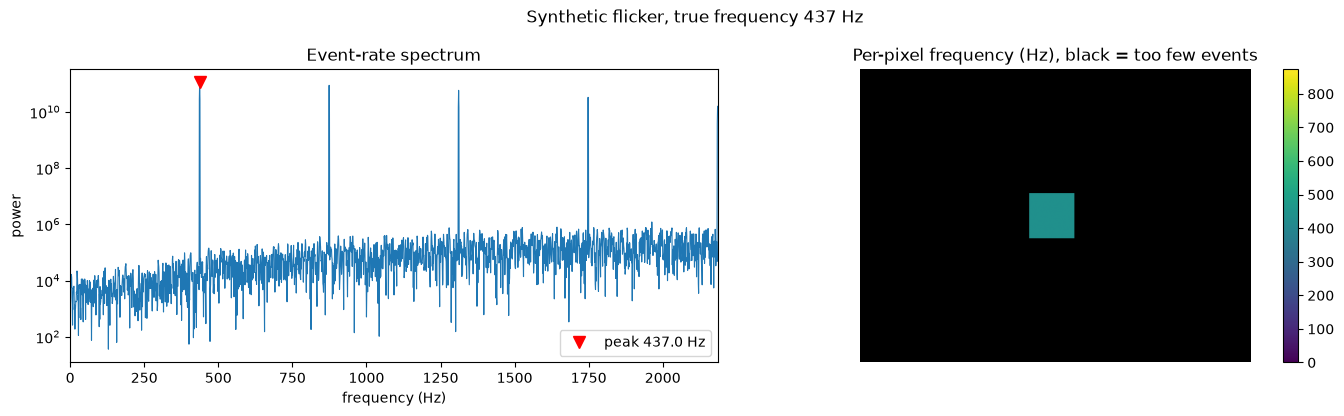

In [4]:
fmap = pixel_frequency_map(ev, SHAPE, polarity=1, min_events=10)
print(f"per-pixel map: {np.isfinite(fmap).sum()} pixels with an estimate, median {np.nanmedian(fmap):.2f} Hz "
      f"({abs(np.nanmedian(fmap) - F_TRUE) / F_TRUE:.2%} error)")
plot_frequency(freqs, power, f_peak, fmap, title=f"Synthetic flicker, true frequency {F_TRUE:.0f} Hz")

## 2. Real recordings

The scene is a light flickering at a known frequency, recorded with the DAVIS346, one file per frequency. A 30 fps camera cannot measure above 15 Hz (Nyquist).

$$f_\text{est} = \frac{\hat f}{N_\text{cycle}}$$

$\hat f$: peak of the event-rate spectrum, $N_\text{cycle}$: `EVENTS_PER_CYCLE`.

The per-pixel map drops every event closer than $0.25 / \hat f$ to the previous event of its pixel.

In [5]:
RECORDINGS = {                 # path -> true frequency in Hz (None if unknown)
    "data/led_0050hz.aedat4": 50,
    "data/led_0120hz.aedat4": 120,
    "data/led_0500hz.aedat4": 500,
    "data/led_1000hz.aedat4": 1000,
    "data/led_3000hz.aedat4": 3000,
}
EVENTS_PER_CYCLE = 1    # LED: 1 flash per cycle. A propeller would use its blade count.
ROI = "auto"            # "auto", None (whole frame) or (x0, y0, x1, y1)
T_START_S, WINDOW_S = 0.5, 2.0
POLARITY = 1            # 1 = ON events only
BIN_US = 50             # event-rate bin; Nyquist = 1 / (2 * BIN_US) = 10 kHz

In [6]:
def rel_err(f, f_true):
    return abs(f - f_true) / f_true if f_true else np.nan


results, first = [], None       # first: data of the first recording found, for the frame comparison below
for path, f_true in RECORDINGS.items():
    if not os.path.exists(path):
        print(f"SKIPPED: {path} not found.")
        continue
    events, frames, sensor_size = load_aedat4(path)
    shape = (sensor_size[1], sensor_size[0])
    t0 = int(T_START_S * 1e6)
    t1 = min(t0 + int(WINDOW_S * 1e6), int(events["t"][-1]))
    if t1 <= t0:
        print(f"SKIPPED: {path} is shorter than T_START_S.")
        continue
    win = events[(events["t"] >= t0) & (events["t"] < t1)]
    roi = busiest_roi(win, shape) if ROI == "auto" else ROI

    freqs, power, f_peak = event_rate_spectrum(events, t0, t1, bin_us=BIN_US, roi=roi, polarity=POLARITY)
    if not np.isfinite(f_peak):
        print(f"SKIPPED: {path} has no spectrum peak in the window.")
        continue
    refractory_us = 0.25e6 / f_peak          # a quarter of the period: longer than a burst, shorter than a cycle
    fmap = pixel_frequency_map(win, shape, polarity=POLARITY, min_events=10, refractory_us=refractory_us)
    in_roi = fmap if roi is None else fmap[roi[1]:roi[3], roi[0]:roi[2]]
    f_spec = f_peak / EVENTS_PER_CYCLE
    f_map = (np.nanmedian(in_roi) if np.isfinite(in_roi).any() else np.nan) / EVENTS_PER_CYCLE

    plot_frequency(freqs, power, f_peak, fmap, roi=roi, f_max=5 * f_peak, title=path)
    print(f"{path}: {len(win):,} events in {(t1 - t0) / 1e6:.2f} s, sensor {shape[1]}x{shape[0]}, ROI {roi}")
    print(f"  refractory period    {refractory_us:.0f} us")
    print(f"  true frequency       " + ("unknown" if f_true is None else f"{f_true:.2f} Hz"))
    print(f"  spectrum estimate    {f_spec:.2f} Hz   error {rel_err(f_spec, f_true):.2%}")
    print(f"  per-pixel median     {f_map:.2f} Hz   error {rel_err(f_map, f_true):.2%}"
          + ("" if roi is None else "   (inside ROI)"))

    results.append({"path": path, "true": f_true, "spectrum": f_spec, "map": f_map})
    if first is None:
        first = {"path": path, "events": events, "frames": frames, "shape": shape, "roi": roi, "t0": t0}

SKIPPED: data/led_0050hz.aedat4 not found.
SKIPPED: data/led_0120hz.aedat4 not found.
SKIPPED: data/led_0500hz.aedat4 not found.


SKIPPED: data/led_1000hz.aedat4 not found.
SKIPPED: data/led_3000hz.aedat4 not found.


In [7]:
if not results:
    print("SKIPPED: no recording found.")
else:
    print(f"{'recording':<28}{'true Hz':>10}{'spectrum Hz':>13}{'error':>9}{'map Hz':>11}{'error':>9}")
    for r in results:
        true = "-" if r["true"] is None else f"{r['true']:.1f}"
        print(f"{os.path.basename(r['path']):<28}{true:>10}{r['spectrum']:>13.2f}{rel_err(r['spectrum'], r['true']):>9.2%}"
              f"{r['map']:>11.2f}{rel_err(r['map'], r['true']):>9.2%}")

    known = [r for r in results if r["true"]]
    if known:
        true = np.array([r["true"] for r in known], dtype=float)
        vals = np.r_[true, [v for r in known for v in (r["spectrum"], r["map"]) if np.isfinite(v)]]
        lim = [0.5 * vals.min(), 2 * vals.max()]
        fig, ax = plt.subplots(figsize=(5.5, 5))
        ax.loglog(lim, lim, "k--", lw=0.8, label="y = x")
        ax.loglog(true, [r["spectrum"] for r in known], "o", ms=8, mfc="none", label="spectrum peak")
        ax.loglog(true, [r["map"] for r in known], "x", ms=8, label="per-pixel median in ROI")
        ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
        ax.set_xlabel("true frequency (Hz)"); ax.set_ylabel("estimated frequency (Hz)")
        ax.set_title("Estimated vs true frequency"); ax.legend(); ax.grid(True, which="both", lw=0.3)
        plt.tight_layout(); plt.show()

SKIPPED: no recording found.


The frames sample at about 30 fps, so a flicker above 15 Hz is aliased or averaged out in them.

In [8]:
SPAN_US = 500_000       # 0.5 s, starting at T_START_S

if first is None:
    print("SKIPPED: no recording found.")
elif len(first["frames"]) == 0 or frames_look_accumulated(first["frames"])[0]:
    print(f"SKIPPED: {first['path']} has no APS frames (missing, or DV Accumulator output).")
else:
    ev, ta = first["events"], first["t0"]
    x0, y0, x1, y1 = first["roi"] if first["roi"] is not None else (0, 0, first["shape"][1], first["shape"][0])
    fr = [f for f in first["frames"] if ta <= f["t"] < ta + SPAN_US]
    m = ((ev["t"] >= ta) & (ev["t"] < ta + SPAN_US) & (ev["p"] == POLARITY)
         & (ev["x"] >= x0) & (ev["x"] < x1) & (ev["y"] >= y0) & (ev["y"] < y1))
    n_bins = SPAN_US // BIN_US
    rate = np.bincount((ev["t"][m] - ta) // BIN_US, minlength=n_bins)[:n_bins] / (BIN_US * 1e-6)

    fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), sharex=True)
    ax[0].plot([f["t"] / 1e6 for f in fr], [np.asarray(f["image"])[y0:y1, x0:x1].mean() for f in fr], "o-")
    ax[0].set_title(f"APS frames: mean brightness in ROI ({len(fr)} frames)"); ax[0].set_ylabel("grey level")
    ax[1].plot((ta + BIN_US * np.arange(n_bins)) / 1e6, rate, lw=0.6)
    ax[1].set_title(f"Events: rate in ROI ({BIN_US} us bins)"); ax[1].set_ylabel("events / s")
    for a in ax:
        a.set_xlabel("time (s)")
    fig.suptitle(first["path"]); plt.tight_layout(); plt.show()

SKIPPED: no recording found.
